In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

# `Customer`

In [2]:
Customer_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Customer Data.xlsx'
Customer=pd.read_excel(Customer_path,dtype={'Customer Name': str ,'Postal Code' : 'Int64'})
Customer=Customer.dropna(how ='all')
Customer

,Customer ID,Customer Name,Client Segment,Country,State,Postal Code,Region
0,12520.0,Claire Gute,Consumer,USA,Kentucky,42420,South
1,13045.0,Darrin Van Huff,Corporate,Egypt,Alex,90036,West
2,20335.0,Sean O'Donnell,Consumer,NaN,Alex,33311,South
11,20065.0,Sandra Flanagan,Consumer,USA,Pennsylvania,19140,East
12,13870.0,Emily Burns,Consumer,USA,Utah,84057,West
...,...,...,...,...,...,...,...
361,19945.0,Ryan Akin,Consumer,United States,California,92563,West
362,17815.0,Meg Tillman,Consumer,United States,Arizona,85254,West
363,21790.0,Vivek Gonzalez,Consumer,United States,California,92037,West
364,15880.0,John Stevenson,Consumer,United States,Washington,98103,West


In [3]:
Customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358 entries, 0 to 365
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer ID     358 non-null    float64
 1   Customer Name   356 non-null    object 
 2   Client Segment  356 non-null    object 
 3   Country         354 non-null    object 
 4   State           358 non-null    object 
 5   Postal Code     358 non-null    Int64  
 6   Region          358 non-null    object 
dtypes: Int64(1), float64(1), object(5)
memory usage: 22.7+ KB


In [4]:
st=Customer[['State','Country']]
st['Country']=st['Country'].replace({'United States':'USA'})
st.query('Country != Country')['State']
##OR
#st[st['Country'].isna()]['State']

# هنا انا استبدلت القيم عشان اوحد و عرفت ايه الوليات الى مش موجوده عندى اسماء بلادهم

/tmp/ipykernel_154/2754731368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  st['Country']=st['Country'].replace({'United States':'USA'})


,State
2,Alex
14,Cairo
15,Texas
20,Tanta


In [5]:
null_Country = st[st['Country'].isna()]
# null_Country
li = null_Country['State'].tolist()
st[st['State'].isin(li)]

# هنا كنت ببشوف هل البلاد دى مكتوبه صح فحتت تانى ولا لا

,State,Country
1,Alex,Egypt
2,Alex,NaN
13,Cairo,Egypt
14,Cairo,NaN
15,Texas,NaN
16,Texas,USA
17,Texas,USA
19,Tanta,Egypt
20,Tanta,NaN
33,Texas,USA


In [6]:
States=Customer[['State','Country']]
States['Country']=States['Country'].replace({'United States':'USA'})
# States['Country'].replace({'United States':'USA'},inplace=True)
States=States.dropna(how='any')
# States=States.dropna(how='any',subset='Country')

# States['Country'].unique()  ## test_code
States.drop_duplicates(subset='State',inplace=True)
States

/tmp/ipykernel_154/4124769629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  States['Country']=States['Country'].replace({'United States':'USA'})


,State,Country
0,Kentucky,USA
1,Alex,Egypt
11,Pennsylvania,USA
12,Utah,USA
13,Cairo,Egypt
16,Texas,USA
18,Illinois,USA
19,Tanta,Egypt
21,Minnesota,USA
22,Michigan,USA


In [7]:
len(States)

39

In [8]:
Customer =pd.merge(Customer,States,on ='State',how='left')
Customer.drop('Country_x',axis=1,inplace=True)
Customer.rename(columns={'Country_y':'Country'},inplace=True)
Customer.head()


,Customer ID,Customer Name,Client Segment,State,Postal Code,Region,Country
0,12520.0,Claire Gute,Consumer,Kentucky,42420,South,USA
1,13045.0,Darrin Van Huff,Corporate,Alex,90036,West,Egypt
2,20335.0,Sean O'Donnell,Consumer,Alex,33311,South,Egypt
3,20065.0,Sandra Flanagan,Consumer,Pennsylvania,19140,East,USA
4,13870.0,Emily Burns,Consumer,Utah,84057,West,USA


In [9]:
# Customer[['Customer ID','Postal Code']]=Customer[['Customer ID','Postal Code']].astype(int)
Customer['Customer ID']=Customer['Customer ID'].astype(int)
Customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     358 non-null    int64 
 1   Customer Name   356 non-null    object
 2   Client Segment  356 non-null    object
 3   State           358 non-null    object
 4   Postal Code     358 non-null    Int64 
 5   Region          358 non-null    object
 6   Country         358 non-null    object
dtypes: Int64(1), int64(1), object(5)
memory usage: 20.1+ KB


**`Product:`**

----------------------


In [10]:
Product_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Products.xlsx'
Product=pd.read_excel(Product_path)
Product.head()

,Product ID,Product Category,Sub-Category,Product Name
0,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [11]:
Product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product ID        710 non-null    int64 
 1   Product Category  710 non-null    object
 2   Sub-Category      710 non-null    object
 3   Product Name      710 non-null    object
dtypes: int64(1), object(3)
memory usage: 22.3+ KB


**Sales Orders files**

In [12]:
folder_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Sales Orders'

In [13]:
dfs=[]
for file in os.listdir(folder_path):
  df=pd.read_csv(folder_path+'/'+file)
  # df=pd.read_csv(os.path.join(folder_path,file))
  df=df[df.columns[0]].str.split(';',expand=True)
  # expand=True : to make each value in colum
  #   df.columns[0] == df['Sales Report 2015']
  df.columns=df.loc[0]
  df=df.drop(0)
  # df.reset_index(drop=True,inplace=True)
  dfs.append(df)
  sales= pd.concat(dfs,axis=0,ignore_index=True)

sales

,Order ID,Order Date,Shipping Date,Ship Mode,Customer ID,Product ID,Quantity,Purchasing Price,Planned Sales Price,Discount
0,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-BO-10001798,2,157.17599999999999,261.95999999999998,0
1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-CH-10000454,3,402.56700000000001,731.93999999999994,0.1
2,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,OFF-LA-10000240,2,8.7719999999999985,14.62,0.05
3,CA-2016-161389,5/12/2016,10/12/2016,Standard Class,IM-15070,OFF-BI-10003656,3,203.98800000000003,407.97600000000006,0.06
4,CA-2016-137330,9/12/2016,13/12/2016,Standard Class,KB-16585,OFF-AR-10000246,7,10.702999999999999,19.459999999999997,0.06
...,...,...,...,...,...,...,...,...,...,...
1002,US-2015-126214,21/12/2015,24/12/2015,Second Class,JS-15880,TEC-AC-10003198,1,49.8,99.6,0.04
1003,CA-2015-133025,17/9/2015,19/9/2015,Second Class,MO-17800,OFF-PA-10004100,5,21.060000000000006,32.400000000000006,0.05
1004,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10002191,2,8.3759999999999994,13.96,0.08
1005,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10000965,3,109.07399999999998,155.82,0.08


In [14]:
def split_v(x,delm):
  return x.split(delm)
sales['Customer ID_2']=sales['Customer ID'].apply(lambda x:split_v(x,'-')[-1])
###OR
sales['Product ID_2']=sales['Product ID'].str.split('-',expand=True)[2]
sales

,Order ID,Order Date,Shipping Date,Ship Mode,Customer ID,Product ID,Quantity,Purchasing Price,Planned Sales Price,Discount,Customer ID_2,Product ID_2
0,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-BO-10001798,2,157.17599999999999,261.95999999999998,0,12520,10001798
1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-CH-10000454,3,402.56700000000001,731.93999999999994,0.1,12520,10000454
2,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,OFF-LA-10000240,2,8.7719999999999985,14.62,0.05,13045,10000240
3,CA-2016-161389,5/12/2016,10/12/2016,Standard Class,IM-15070,OFF-BI-10003656,3,203.98800000000003,407.97600000000006,0.06,15070,10003656
4,CA-2016-137330,9/12/2016,13/12/2016,Standard Class,KB-16585,OFF-AR-10000246,7,10.702999999999999,19.459999999999997,0.06,16585,10000246
...,...,...,...,...,...,...,...,...,...,...,...,...
1002,US-2015-126214,21/12/2015,24/12/2015,Second Class,JS-15880,TEC-AC-10003198,1,49.8,99.6,0.04,15880,10003198
1003,CA-2015-133025,17/9/2015,19/9/2015,Second Class,MO-17800,OFF-PA-10004100,5,21.060000000000006,32.400000000000006,0.05,17800,10004100
1004,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10002191,2,8.3759999999999994,13.96,0.08,16225,10002191
1005,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10000965,3,109.07399999999998,155.82,0.08,16225,10000965


In [15]:
sales.drop(['Product ID', 'Customer ID'], axis = 1, inplace = True)

In [16]:
sales.rename(columns={'Customer ID_2':'Customer ID','Product ID_2':'Product ID'},inplace=True)
sales

,Order ID,Order Date,Shipping Date,Ship Mode,Quantity,Purchasing Price,Planned Sales Price,Discount,Customer ID,Product ID
0,CA-2016-152156,8/11/2016,11/11/2016,Second Class,2,157.17599999999999,261.95999999999998,0,12520,10001798
1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,3,402.56700000000001,731.93999999999994,0.1,12520,10000454
2,CA-2016-138688,12/6/2016,16/6/2016,Second Class,2,8.7719999999999985,14.62,0.05,13045,10000240
3,CA-2016-161389,5/12/2016,10/12/2016,Standard Class,3,203.98800000000003,407.97600000000006,0.06,15070,10003656
4,CA-2016-137330,9/12/2016,13/12/2016,Standard Class,7,10.702999999999999,19.459999999999997,0.06,16585,10000246
...,...,...,...,...,...,...,...,...,...,...
1002,US-2015-126214,21/12/2015,24/12/2015,Second Class,1,49.8,99.6,0.04,15880,10003198
1003,CA-2015-133025,17/9/2015,19/9/2015,Second Class,5,21.060000000000006,32.400000000000006,0.05,17800,10004100
1004,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,2,8.3759999999999994,13.96,0.08,16225,10002191
1005,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,3,109.07399999999998,155.82,0.08,16225,10000965


In [17]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Order ID             1007 non-null   object
 1   Order Date           1007 non-null   object
 2   Shipping Date        1007 non-null   object
 3   Ship Mode            1007 non-null   object
 4   Quantity             1007 non-null   object
 5   Purchasing Price     1007 non-null   object
 6   Planned Sales Price  1007 non-null   object
 7   Discount             1007 non-null   object
 8   Customer ID          1007 non-null   object
 9   Product ID           1007 non-null   object
dtypes: object(10)
memory usage: 78.8+ KB


In [18]:
sales['Quantity'] = sales['Quantity'].astype(int)
sales[['Purchasing Price', 'Planned Sales Price', 'Discount']] = sales[['Purchasing Price', 'Planned Sales Price', 'Discount']].astype(float)
sales['Order Date'] = pd.to_datetime(sales['Order Date'], format = "%d/%m/%Y")
sales['Shipping Date'] = pd.to_datetime(sales['Shipping Date'], format = "%d/%m/%Y")
sales[['Customer ID','Product ID']]=sales[['Customer ID','Product ID']].astype(int)
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Quantity             1007 non-null   int64         
 5   Purchasing Price     1007 non-null   float64       
 6   Planned Sales Price  1007 non-null   float64       
 7   Discount             1007 non-null   float64       
 8   Customer ID          1007 non-null   int64         
 9   Product ID           1007 non-null   int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(2)
memory usage: 78.8+ KB


In [19]:
sales['Final Price']=sales['Planned Sales Price']*(1-sales['Discount'])
sales['Profit']=(sales['Final Price']-sales['Purchasing Price'])
sales['Month'] = sales['Order Date'].dt.month
sales['Shipping_Days']=(sales['Shipping Date']-sales['Order Date']).dt.days
# *sales['Quantity']
sales

,Order ID,Order Date,Shipping Date,Ship Mode,Quantity,Purchasing Price,Planned Sales Price,Discount,Customer ID,Product ID,Final Price,Profit,Month,Shipping_Days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,2,157.176,261.960,0.00,12520,10001798,261.96000,104.78400,11,3
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,3,402.567,731.940,0.10,12520,10000454,658.74600,256.17900,11,3
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,2,8.772,14.620,0.05,13045,10000240,13.88900,5.11700,6,4
3,CA-2016-161389,2016-12-05,2016-12-10,Standard Class,3,203.988,407.976,0.06,15070,10003656,383.49744,179.50944,12,5
4,CA-2016-137330,2016-12-09,2016-12-13,Standard Class,7,10.703,19.460,0.06,16585,10000246,18.29240,7.58940,12,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,US-2015-126214,2015-12-21,2015-12-24,Second Class,1,49.800,99.600,0.04,15880,10003198,95.61600,45.81600,12,3
1003,CA-2015-133025,2015-09-17,2015-09-19,Second Class,5,21.060,32.400,0.05,17800,10004100,30.78000,9.72000,9,2
1004,CA-2015-108665,2015-07-06,2015-07-10,Standard Class,2,8.376,13.960,0.08,16225,10002191,12.84320,4.46720,7,4
1005,CA-2015-108665,2015-07-06,2015-07-10,Standard Class,3,109.074,155.820,0.08,16225,10000965,143.35440,34.28040,7,4


In [20]:
sales['H&L'] = np.where(sales['Profit'] > 0, 'Hit', 'Loss')
#OR
# sales['H&L'] = sales['Profit'].apply(lambda x: 'Hit' if x > 0 else 'Loss')

In [21]:
sales.groupby('H&L').agg({'Profit':'count'})

,Profit
H&L,
Hit,1007


In [22]:
final=pd.merge(sales,Customer,on='Customer ID',how='left')
final_df=pd.merge(final,Product,on='Product ID',how='left')
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Quantity             1007 non-null   int64         
 5   Purchasing Price     1007 non-null   float64       
 6   Planned Sales Price  1007 non-null   float64       
 7   Discount             1007 non-null   float64       
 8   Customer ID          1007 non-null   int64         
 9   Product ID           1007 non-null   int64         
 10  Final Price          1007 non-null   float64       
 11  Profit               1007 non-null   float64       
 12  Month                1007 non-null   int32         
 13  Shipping_Days        1007 non-nul

In [23]:
final_df['Shipping_Days'] = (final_df['Shipping Date'] - final_df['Order Date']).dt.days
final_df['Shipping_Days'].mean()

np.float64(4.009930486593843)

In [24]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Quantity             1007 non-null   int64         
 5   Purchasing Price     1007 non-null   float64       
 6   Planned Sales Price  1007 non-null   float64       
 7   Discount             1007 non-null   float64       
 8   Customer ID          1007 non-null   int64         
 9   Product ID           1007 non-null   int64         
 10  Final Price          1007 non-null   float64       
 11  Profit               1007 non-null   float64       
 12  Month                1007 non-null   int32         
 13  Shipping_Days        1007 non-nul

In [25]:
# final_df.to_csv('Sales_Orders_Project.csv', index=False)

**Customer Dashboard**

In [26]:
Customer.head()

,Customer ID,Customer Name,Client Segment,State,Postal Code,Region,Country
0,12520,Claire Gute,Consumer,Kentucky,42420,South,USA
1,13045,Darrin Van Huff,Corporate,Alex,90036,West,Egypt
2,20335,Sean O'Donnell,Consumer,Alex,33311,South,Egypt
3,20065,Sandra Flanagan,Consumer,Pennsylvania,19140,East,USA
4,13870,Emily Burns,Consumer,Utah,84057,West,USA


In [27]:
c1=final_df.groupby('Client Segment')['Customer ID'].count().reset_index(name='Count')
display(c1)

px.pie(
    c1,
    values="Count",
    names="Client Segment",
    title="Total Sales by Payment Type",
    width=600,
    height=400
)

,Client Segment,Count
0,Consumer,523
1,Corporate,281
2,Home Office,163


In [28]:
c2=final_df.groupby('Region')['Customer ID'].count().reset_index(name='Count')
display(c2)
px.bar(data_frame=c2,x='Region',y='Count',color='Region', height=350,width=700,title='Customers by Region')

,Region,Count
0,Central,251
1,East,324
2,South,133
3,West,272


In [29]:
c3=final_df.groupby('State')['Customer ID'].count().reset_index(name='Count').sort_values(by='Count',ascending=False)
display(c3)

,State,Count
5,California,160
25,New York,141
34,Texas,95
30,Pennsylvania,70
11,Illinois,60
27,Ohio,58
6,Colorado,35
18,Michigan,35
9,Florida,33
37,Washington,32


In [30]:
c=final_df.groupby(['Customer ID','Customer Name','Client Segment'])['Final Price'].sum().reset_index(name='Total_Sales').sort_values(by='Total_Sales',ascending=False).head(10)
display(c)

fig = px.bar(data_frame=c,x="Customer Name",y="Total_Sales",color='Customer Name')
fig.update_layout(
    title_text="Sales Distribution by Branch",
    height=350,
    width=700,
    showlegend=False
)
fig.show()


,Customer ID,Customer Name,Client Segment,Total_Sales
135,14635,Grant Thornton,Corporate,7760.72340
33,11140,Becky Martin,Consumer,7522.89584
65,12385,Christopher Martinez,Consumer,6092.18630
312,20290,Sean Braxton,Corporate,5443.14162
249,18445,Nathan Mautz,Home Office,4567.00340
4,10180,Alan Dominguez,Home Office,4535.18900
290,19795,Ross Baird,Home Office,4194.90124
0,10060,Adam Bellavance,Home Office,4171.70288
192,16510,Keith Herrera,Consumer,3798.96797
101,13480,Dianna Wilson,Home Office,3490.40710


**Product Dashboard**


---




In [31]:
Product.head()

,Product ID,Product Category,Sub-Category,Product Name
0,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [32]:
p1=final_df.groupby('Product Category')['Sub-Category'].nunique().reset_index(name='Sub-Category').sort_values(by='Sub-Category',ascending=False)
display(p1)
# len(final_df['Sub-Category'].unique())
px.pie(
    p1,
    values="Sub-Category",
    names="Product Category",
    width=600,
    height=400,
    title='Total Sub-Category by Product Category'
    )

,Product Category,Sub-Category
1,Office Supplies,9
0,Furniture,4
2,Technology,4


,Product Category,Sub-Category,Count
0,Furniture,Bookcases,18
1,Furniture,Chairs,53
2,Furniture,Furnishings,85
3,Furniture,Tables,35
4,Office Supplies,Appliances,40
5,Office Supplies,Art,88
6,Office Supplies,Binders,152
7,Office Supplies,Envelopes,33
8,Office Supplies,Fasteners,24
9,Office Supplies,Labels,38


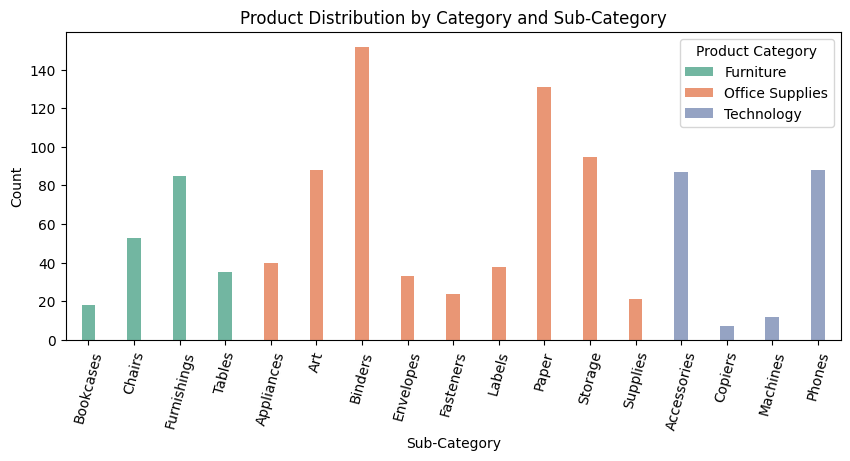

In [33]:
p4 = final_df.groupby(['Product Category', 'Sub-Category']).size().reset_index(name='Count')
display(p4)

plt.figure(figsize=(10,4))
sns.barplot(
    data=p4,
    x='Sub-Category',
    y='Count',
    hue='Product Category',
    palette="Set2",
    width=0.3
)
plt.title("Product Distribution by Category and Sub-Category")
plt.xticks(rotation=75)
plt.ylabel("Count")
plt.show()


In [34]:
p2=final_df.groupby('Product Category')['Quantity'].sum().reset_index(name='Quantity').sort_values(by='Quantity',ascending=False)
display(p2)
px.bar(data_frame=p2,x='Product Category',y='Quantity',color='Product Category',width=500,height=350)

,Product Category,Quantity
1,Office Supplies,2343
2,Technology,749
0,Furniture,746


In [35]:
# p4 = final_df.groupby(['Product Category', 'Sub-Category']).size().reset_index(name='Count')
# display(p4)

# px.bar(p4, x = "Product Category", y = "Count",
#              color = "Sub-Category", title = "Long-Form Input",width=600)

In [36]:
p3=final_df.groupby('Product Category')['Final Price'].sum().reset_index(name='Final Price').sort_values(by='Final Price',ascending=False)
display(p3)
px.pie(
    p3,
    values="Final Price",
    names="Product Category",
    width=400,
    height=300,
    hole=.8)

,Product Category,Final Price
2,Technology,89037.879990
0,Furniture,68972.057342
1,Office Supplies,67970.597480


**Sales Order**

---



In [37]:
sales.columns

Index(['Order ID', 'Order Date', 'Shipping Date', 'Ship Mode', 'Quantity',
       'Purchasing Price', 'Planned Sales Price', 'Discount', 'Customer ID',
       'Product ID', 'Final Price', 'Profit', 'Month', 'Shipping_Days', 'H&L'],
      dtype='object', name=0)

,Month,Final Price
0,1,13269.928000
1,2,2247.426600
2,3,11445.754830
3,4,12832.422855
4,5,14687.366480
5,6,23097.328890
6,7,9826.257480
7,8,10736.288330
8,9,45062.140596
9,10,15554.639415


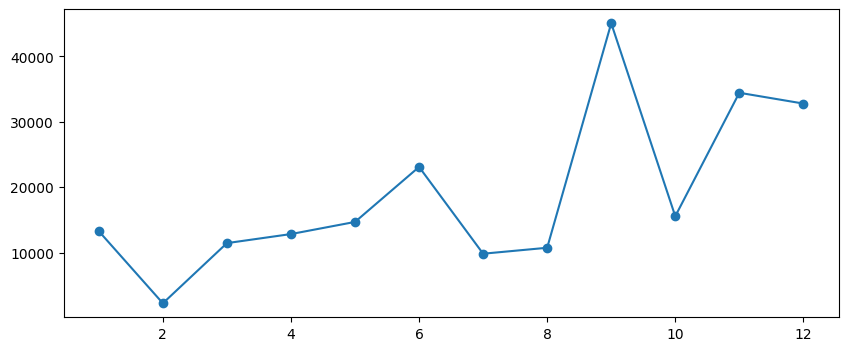

In [38]:
s1=final_df.groupby('Month')['Final Price'].sum().reset_index()
display(s1)
plt.figure(figsize=(10,4))
plt.plot(s1['Month'],s1['Final Price'],marker='o',linestyle='-')
plt.show()

In [54]:
s2=final_df.groupby('Region',dropna=False)['Final Price'].sum().reset_index()
# هنا انا شوفت ان فى منطقه مش معروفه
display(s2)
px.bar(data_frame=s2,x='Region',y='Final Price',color='Region',width=650,height=350)

,Region,Final Price
0,Central,66195.512897
1,East,54881.317590
2,South,42722.392105
3,West,55589.753160
4,NaN,6591.559060


In [65]:
# display(sales['Customer ID'].nunique())
# display(Customer['Customer ID'].nunique())


In [64]:
sales_c=sales['Customer ID'].nunique()
Customer_c=Customer['Customer ID'].nunique()
print(f"Sales in Sales Files :  {sales_c}")
print(f"Customer in Sales Files : {Customer_c}")
############
print("Number of ids :")
not_konw=sales[final_df['Customer Name'].isna()]['Customer ID'].unique()
# not_konw['Customer ID'].unique()
print(f"Number of ids :{not_konw}")
#


Sales in Sales Files :  366
Customer in Sales Files : 358
Number of ids :
Number of ids :[15070 16585 19075 11710 10270 21925 10480 17560 21520 14815]


In [69]:
### Top 10 Customer
# cc2=final_df.groupby(['Customer ID','Customer Name'])['Final Price'].sum().reset_index().sort_values(by='Final Price',ascending=False).head(10)
# cc2

In [44]:
s3=final_df.groupby('Region')['Final Price'].sum().reset_index()
display(s3)
px.bar(data_frame=s3,x='Region',y='Final Price',color='Region',width=600,height=350)

,Region,Final Price
0,Central,66195.512897
1,East,54881.317590
2,South,42722.392105
3,West,55589.753160


In [45]:
final_df['Order Date'].dt.year.unique()

array([2016, 2014, 2017, 2015], dtype=int32)

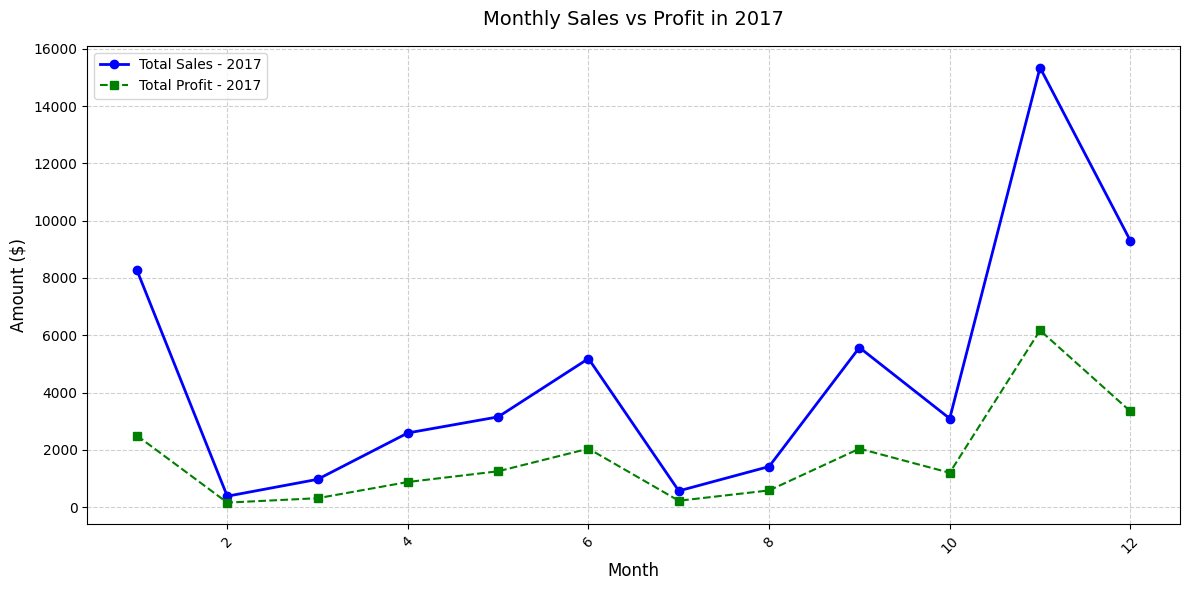

In [46]:
target_year = 2017

filtered_data = final_df[final_df['Order Date'].dt.year == target_year]

s4 = filtered_data.groupby('Month').agg({
    'Final Price': 'sum',
    'Profit': 'sum'
}).reset_index()

plt.figure(figsize=(12, 6))

plt.plot(s4['Month'], s4['Final Price'],
         label=f'Total Sales - {target_year}', marker='o', color='b', linewidth=2)

plt.plot(s4['Month'], s4['Profit'],
         label=f'Total Profit - {target_year}', marker='s', color='g', linestyle='--')

plt.title(f'Monthly Sales vs Profit in {target_year}', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

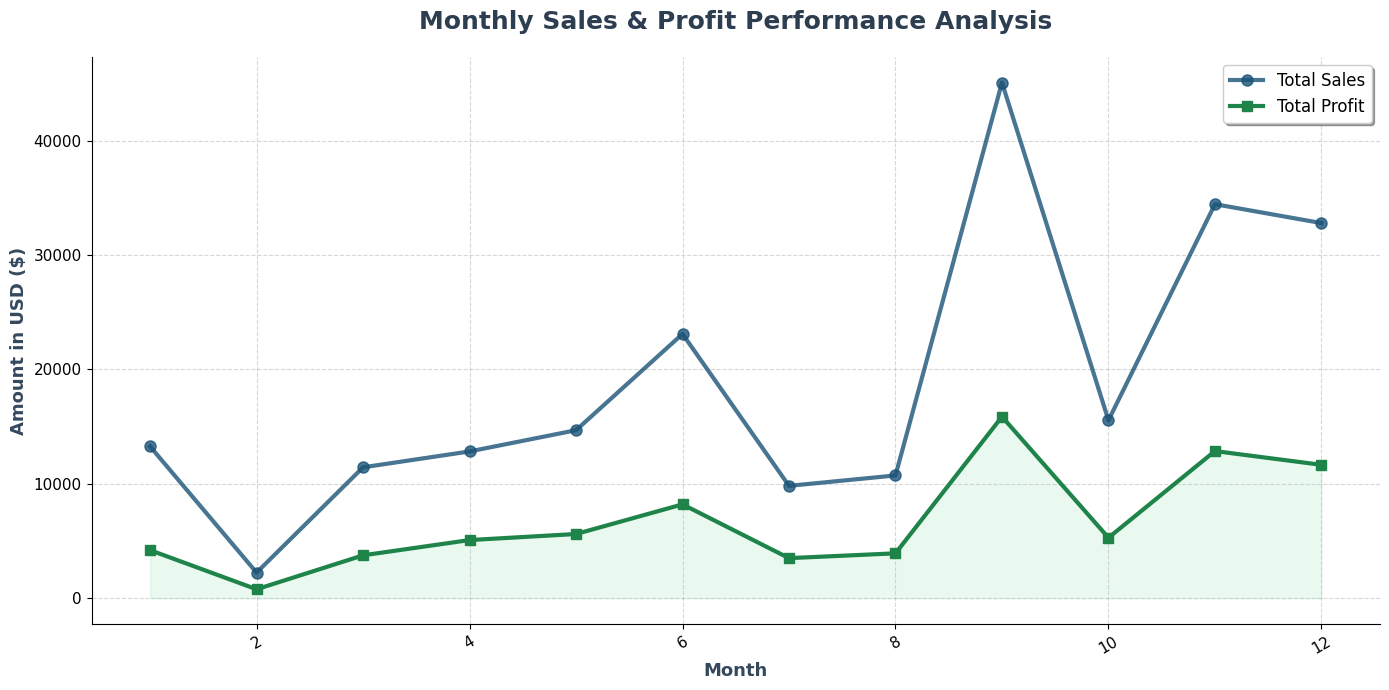

In [78]:
# تجهيز البيانات (تأكد من تشغيل كود s4 أولاً)
plt.figure(figsize=(14, 7))

# رسم خط المبيعات بأسلوب ناعم وألوان احترافية
plt.plot(s4['Month'], s4['Final Price'],
         marker='o', markersize=8, color='#1A5276', linewidth=3,
         label='Total Sales', alpha=0.8)

# رسم خط الربح مع إضافة منطقة مظللة (Area) لتمييزه
plt.plot(s4['Month'], s4['Profit'],
         marker='s', markersize=7, color='#1E8449', linewidth=3,
         label='Total Profit', linestyle='-')

# ملء المساحة تحت خط الربح لتعطي شكلاً جمالياً وتوضح "منطقة الأمان"
plt.fill_between(s4['Month'], s4['Profit'], color='#2ECC71', alpha=0.1)

# تحسين العناوين والخطوط
plt.title('Monthly Sales & Profit Performance Analysis', fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Month', fontsize=13, fontweight='bold', color='#34495E')
plt.ylabel('Amount in USD ($)', fontsize=13, fontweight='bold', color='#34495E')

# تحسين شكل المحاور وتدوير الشهور لسهولة القراءة
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

# إضافة شبكة خلفية باهتة لعدم تشتيت العين
plt.grid(True, linestyle='--', alpha=0.5)

# إزالة الحواف العلوية واليمنى لإعطاء مظهر عصري (Clean Look)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# إضافة دليل الألوان في مكان مميز
plt.legend(fontsize=12, frameon=True, shadow=True)

# ضبط المسافات التلقائية
plt.tight_layout()

plt.show()

,Discount_Rate,Avg_Quantity,Total_Profit,Transaction_Count
4,0.05,3.815789,24745.188550,266
7,0.08,3.850340,10571.826276,147
5,0.06,3.688889,8726.231400,135
0,0.00,3.820000,8359.567400,150
6,0.07,3.892473,8051.513440,93
8,0.09,4.346667,6224.545740,75
3,0.04,3.425000,4183.162706,40
2,0.03,3.333333,3974.485260,51
1,0.02,3.058824,2408.908950,17
13,0.15,5.666667,2351.937900,9


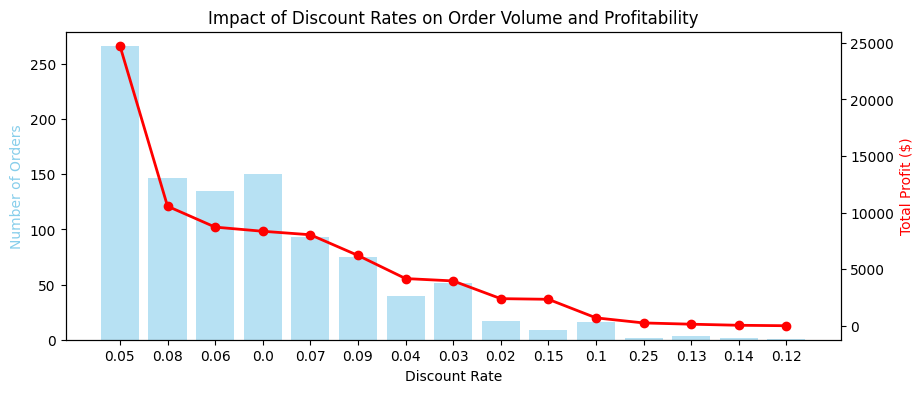

In [79]:
# تجميع البيانات حسب نسبة الخصم
discount_effect = final_df.groupby('Discount').agg({
    'Quantity': 'mean',      # متوسط الكمية المبيعة في الطلبية الواحدة
    'Profit': 'sum',        # إجمالي الأرباح عند هذا الخصم
    'Order ID': 'count'     # عدد الطلبيات التي تمت بهذا الخصم
}).reset_index().sort_values(by='Profit',ascending=False)
# discount_effect
# إعادة تسمية الأعمدة لتكون واضحة
discount_effect.columns = ['Discount_Rate', 'Avg_Quantity', 'Total_Profit', 'Transaction_Count']
display(discount_effect)



fig, ax1 = plt.subplots(figsize=(10, 4))

# الرسم الأول: عدد الطلبيات (Bar Chart)
ax1.bar(discount_effect['Discount_Rate'].astype(str), discount_effect['Transaction_Count'], color='skyblue', alpha=0.6, label='Number of Orders')
ax1.set_xlabel('Discount Rate')
ax1.set_ylabel('Number of Orders', color='skyblue')

# الرسم الثاني: إجمالي الربح (Line Chart) على نفس الرسم
ax2 = ax1.twinx()
ax2.plot(discount_effect['Discount_Rate'].astype(str), discount_effect['Total_Profit'], color='red', marker='o', linewidth=2, label='Total Profit')
ax2.set_ylabel('Total Profit ($)', color='red')

plt.title('Impact of Discount Rates on Order Volume and Profitability')
plt.show()

'Average Shipping Days: 4.01 days'

-----------------


,Shipping_Days,Final Price,Profit,Order ID
0,0,827.388660,350.688728,19
1,1,96.130254,38.658947,29
2,2,259.525370,95.297915,182
3,3,177.119756,66.103227,103
4,4,200.089571,66.599543,283
5,5,232.373381,79.768211,210
6,6,215.257621,76.674927,113
7,7,180.111039,67.701698,68


-----------------


/tmp/ipykernel_154/2525874153.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




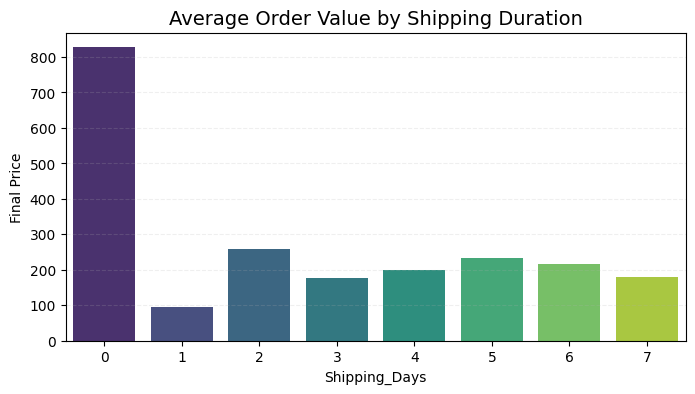

In [48]:
# final_df[final_df['Shipping_Days'] >= 0]
avg_shipping = final_df['Shipping_Days'].mean()
display(f"Average Shipping Days: {avg_shipping:.2f} days")
print("-----------------")
shipping_impact = final_df.groupby('Shipping_Days').agg({
    'Final Price': 'mean',  # متوسط قيمة الطلبية
    'Profit': 'mean',       # متوسط الربح
    'Order ID': 'count'     # عدد الطلبيات
}).reset_index()

display(shipping_impact)
print("-----------------")
plt.figure(figsize=(8, 4))
sns.barplot(data=shipping_impact, x='Shipping_Days', y='Final Price', palette='viridis')

plt.title('Average Order Value by Shipping Duration', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.show()

In [49]:
# مقارنة متوسط الأيام لكل نوع شحن
ship_mode_analysis = final_df.groupby('Ship Mode')['Shipping_Days'].mean()
ship_mode_analysis

,Shipping_Days
Ship Mode,
First Class,2.210811
Same Day,0.000000
Second Class,3.193548
Standard Class,5.010239


In [50]:
final_df.columns

Index(['Order ID', 'Order Date', 'Shipping Date', 'Ship Mode', 'Quantity',
       'Purchasing Price', 'Planned Sales Price', 'Discount', 'Customer ID',
       'Product ID', 'Final Price', 'Profit', 'Month', 'Shipping_Days', 'H&L',
       'Customer Name', 'Client Segment', 'State', 'Postal Code', 'Region',
       'Country', 'Product Category', 'Sub-Category', 'Product Name'],
      dtype='object')

# `Test Code`

In [51]:
  # df=df[df.columns[0]].str.split(';',expand=True)
  # df.columns=df.loc[0]
  # # df['Sales Report 2015']

  # # df_copy['Customer ID'][2]
  # for i in df_copy['Customer ID']:
  #   df_copy['new_id']=int(df_copy['Customer ID'][i].split('-')[1])
  # df_copy

# df_copy['Customer ID'][2].split('-')[1]
# print(int(df_copy['Customer ID'][2].str.split('-')[0][1]))
# df_copy

In [52]:
df_copy=df
df_copy

for i in df_copy.index:
    value = df_copy.loc[i, 'Customer ID']
    df_copy.loc[i, 'new_id'] = int(value.split('-')[1])
df_copy['new_id']=df_copy['new_id'].astype(int)
df_copy

,Order ID,Order Date,Shipping Date,Ship Mode,Customer ID,Product ID,Quantity,Purchasing Price,Planned Sales Price,Discount,new_id
1,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,FUR-TA-10000577,5,478.78874999999999,957.57749999999999,0.070000000000000007,20335
2,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,OFF-ST-10000760,2,11.184000000000001,22.368000000000002,0.09,20335
3,US-2015-118983,22/11/2015,26/11/2015,Standard Class,HP-14815,OFF-AP-10002311,5,34.404999999999994,68.809999999999988,0,14815
4,US-2015-118983,22/11/2015,26/11/2015,Standard Class,HP-14815,OFF-BI-10000756,3,1.6535999999999997,2.5439999999999996,0,14815
5,CA-2015-106320,25/9/2015,30/9/2015,Standard Class,EB-13870,FUR-TA-10000577,3,522.31499999999994,1044.6299999999999,0.04,13870
...,...,...,...,...,...,...,...,...,...,...,...
209,US-2015-126214,21/12/2015,24/12/2015,Second Class,JS-15880,TEC-AC-10003198,1,49.8,99.6,0.04,15880
210,CA-2015-133025,17/9/2015,19/9/2015,Second Class,MO-17800,OFF-PA-10004100,5,21.060000000000006,32.400000000000006,0.05,17800
211,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10002191,2,8.3759999999999994,13.96,0.08,16225
212,CA-2015-108665,6/7/2015,10/7/2015,Standard Class,KM-16225,FUR-FU-10000965,3,109.07399999999998,155.82,0.08,16225
